# 01 - EDA Olympic AI2025 Dataset

Mục tiêu của notebook này không chỉ là download dataset, mà là tạo bằng chứng để giải thích các quyết định ở notebook train: số frame cố định, resize/crop, augmentation nhất quán, balanced sampling, và các rủi ro như video lỗi/trùng lặp.


In [1]:
# ============================================================
# CONFIG - Google Drive stores data and metadata
# ============================================================
PROJECT_ROOT = "/content/drive/MyDrive/vsl-recognition"

OLYMPIC_FOLDER_ID = "1X3xTeaI8keWD4c-cePjN-xboJGOgQ66A"
DATASET_ZIP_FILE_ID = "1WRJA4-8ymdQXx9riUUEDm-8H08j0lVvV"

DATA_DIR = f"{PROJECT_ROOT}/data/olympic_ai2025"
DATASET_ZIP_PATH = f"{DATA_DIR}/dataset.zip"
METADATA_DIR = f"{PROJECT_ROOT}/metadata"

VAL_RATIO = 0.2
SEED = 42
VIDEO_EXTENSIONS = (".avi", ".mp4", ".mov", ".mkv", ".webm")

# Full EDA is recommended before training. Set to 300 only for a quick notebook smoke run.
MAX_VIDEO_PROBE = None

# Bad-frame scan reads sampled frames from each video, not every frame, so it is useful but conservative.
BAD_FRAME_SAMPLE_COUNT = 16
DUPLICATE_SIGNATURE_FRAMES = 5


## 1. Setup Environment


In [2]:
import os
import sys
import json
import pickle
import random
import zipfile
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    !pip install -q gdown decord opencv-python-headless pandas matplotlib seaborn tqdm pillow
else:
    print("Not running in Colab. PROJECT_ROOT is still:", PROJECT_ROOT)
    print("Use Colab for the Drive-first workflow, or edit PROJECT_ROOT for a local dry run.")

import cv2
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
for p in [DATA_DIR, METADATA_DIR]:
    Path(p).mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("METADATA_DIR:", METADATA_DIR)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 72.1 MB/s eta 0:00:00
PROJECT_ROOT: /content/drive/MyDrive/vsl-recognition
DATA_DIR: /content/drive/MyDrive/vsl-recognition/data/olympic_ai2025
METADATA_DIR: /content/drive/MyDrive/vsl-recognition/metadata


## 2. Download And Locate Dataset

Câu hỏi: dataset có đúng cấu trúc mà pipeline train cần không? Kỳ vọng là có `train/`, `public_test/`, `private_test/`, và `label_mapping.pkl`.


In [3]:
data_dir = Path(DATA_DIR)
zip_path = Path(DATASET_ZIP_PATH)

if not zip_path.exists():
    print("Downloading dataset.zip to Google Drive...")
    gdown.download(id=DATASET_ZIP_FILE_ID, output=str(zip_path), quiet=False, fuzzy=True)
else:
    print("dataset.zip already exists:", zip_path)

def find_dataset_root(base_dir: Path) -> Path:
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "label_mapping.pkl").exists():
            return candidate
    raise FileNotFoundError("Could not find a folder containing train/ and label_mapping.pkl")

try:
    DATASET_ROOT = find_dataset_root(data_dir)
    print("Dataset already extracted:", DATASET_ROOT)
except FileNotFoundError:
    print("Extracting dataset.zip. This can take a few minutes on Drive...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)
    DATASET_ROOT = find_dataset_root(data_dir)
    print("Extracted dataset root:", DATASET_ROOT)

TRAIN_DIR = DATASET_ROOT / "train"
PUBLIC_TEST_DIR = DATASET_ROOT / "public_test"
PRIVATE_TEST_DIR = DATASET_ROOT / "private_test"
LABEL_MAPPING_PATH = DATASET_ROOT / "label_mapping.pkl"

print("TRAIN_DIR:", TRAIN_DIR)
print("PUBLIC_TEST_DIR exists:", PUBLIC_TEST_DIR.exists())
print("PRIVATE_TEST_DIR exists:", PRIVATE_TEST_DIR.exists())
print("LABEL_MAPPING_PATH:", LABEL_MAPPING_PATH)


dataset.zip already exists: /content/drive/MyDrive/vsl-recognition/data/olympic_ai2025/dataset.zip
Dataset already extracted: /content/drive/MyDrive/vsl-recognition/data/olympic_ai2025/dataset
TRAIN_DIR: /content/drive/MyDrive/vsl-recognition/data/olympic_ai2025/dataset/train
PUBLIC_TEST_DIR exists: True
PRIVATE_TEST_DIR exists: True
LABEL_MAPPING_PATH: /content/drive/MyDrive/vsl-recognition/data/olympic_ai2025/dataset/label_mapping.pkl


## 3. Labels And File Inventory

Câu hỏi: có bao nhiêu lớp, bao nhiêu video, tên lớp từ folder có khớp `label_mapping.pkl` không?


In [4]:
with open(LABEL_MAPPING_PATH, "rb") as f:
    raw_label_mapping = pickle.load(f)

class_dirs = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()], key=lambda p: p.name)
print("Raw label_mapping type:", type(raw_label_mapping))
print("Class folders:", len(class_dirs))
print("First folders:", [p.name for p in class_dirs[:10]])

def _intlike(x):
    try:
        int(x)
        return True
    except Exception:
        return False

def normalize_label_mapping(mapping, folders):
    folder_names = [p.name for p in folders]
    folder_set = set(folder_names)
    class_to_old_idx = {}
    idx_to_display = {}

    if isinstance(mapping, dict) and mapping:
        if all(_intlike(v) for v in mapping.values()):
            idx_to_display = {int(v): str(k) for k, v in mapping.items()}
            if any(str(k) in folder_set for k in mapping.keys()):
                class_to_old_idx = {str(k): int(v) for k, v in mapping.items() if str(k) in folder_set}
            elif all(_intlike(name) for name in folder_names):
                class_to_old_idx = {name: int(name) for name in folder_names}
        elif all(_intlike(k) for k in mapping.keys()):
            idx_to_display = {int(k): str(v) for k, v in mapping.items()}
            if all(_intlike(name) for name in folder_names):
                class_to_old_idx = {name: int(name) for name in folder_names}
            else:
                reverse = {str(v): int(k) for k, v in mapping.items()}
                class_to_old_idx = {name: reverse[name] for name in folder_names if name in reverse}

    if not class_to_old_idx:
        class_to_old_idx = {name: idx for idx, name in enumerate(folder_names)}

    missing = [name for name in folder_names if name not in class_to_old_idx]
    next_idx = max(class_to_old_idx.values(), default=-1) + 1
    for name in missing:
        class_to_old_idx[name] = next_idx
        next_idx += 1

    old_indices = sorted(set(class_to_old_idx.values()))
    remap = {old_idx: new_idx for new_idx, old_idx in enumerate(old_indices)}
    class_to_idx = {name: remap[old_idx] for name, old_idx in class_to_old_idx.items()}
    folder_by_old_idx = {old_idx: name for name, old_idx in class_to_old_idx.items()}
    class_names = [idx_to_display.get(old_idx, folder_by_old_idx.get(old_idx, str(old_idx))) for old_idx in old_indices]
    return class_to_idx, class_names

class_to_idx, class_names = normalize_label_mapping(raw_label_mapping, class_dirs)

all_items = []
class_counts = Counter()
for class_dir in class_dirs:
    label = class_to_idx[class_dir.name]
    videos = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in VIDEO_EXTENSIONS])
    class_counts[class_dir.name] = len(videos)
    for video_path in videos:
        all_items.append({
            "path": str(video_path),
            "label": label,
            "class_name": class_dir.name,
            "video_name": video_path.name,
        })

def count_videos(folder: Path):
    if not folder.exists():
        return 0
    return len([p for p in folder.rglob("*") if p.suffix.lower() in VIDEO_EXTENSIONS])

print("Normalized classes:", len(class_names))
print("Total train videos:", len(all_items))
print("Public test videos:", count_videos(PUBLIC_TEST_DIR))
print("Private test videos:", count_videos(PRIVATE_TEST_DIR))
print("First 10 class names:", class_names[:10])


Raw label_mapping type: <class 'dict'>
Class folders: 100
First folders: ['An ủi', 'Áp dụng', 'Ăn', 'Ăn mừng', 'Ban ngày', 'Ban đêm', 'Bàn tay', 'Băn khoăn', 'Bạn thân', 'Bế mạc']
Normalized classes: 100
Total train videos: 3875
Public test videos: 1630
Private test videos: 2859
First 10 class names: ['An ủi', 'Áp dụng', 'Ăn', 'Ăn mừng', 'Ban ngày', 'Ban đêm', 'Bàn tay', 'Băn khoăn', 'Bạn thân', 'Bế mạc']


## 4. EDA - Class Imbalance

Câu hỏi: class có mất cân bằng không? Nếu có long-tail rõ, notebook train mới có lý do dùng `WeightedRandomSampler` hoặc cân nhắc weighted loss.


Class count summary:
count    100.000000
mean      38.750000
std       22.776638
min        6.000000
25%       15.750000
50%       45.500000
75%       59.000000
max       74.000000
dtype: float64
Imbalance ratio max/min: 12.33
Head/body/tail groups:
body    49
head    26
tail    25
Name: count, dtype: int64
Top 10 classes:
Trường học    74
Rau               72
Áp dụng         71
Nhà              71
Chậm lại       69
Nghe              68
Cám dỗ         68
Nói xấu        68
Biết            67
Phía sau         67
dtype: int64
Bottom 10 classes:
Lo lắng       7
Học sinh       7
Cơ thể       6
Cách ly        6
Bệnh nhân    6
Ho              6
Phục hồi     6
Sốt           6
Xe máy         6
Ủng hộ       6
dtype: int64


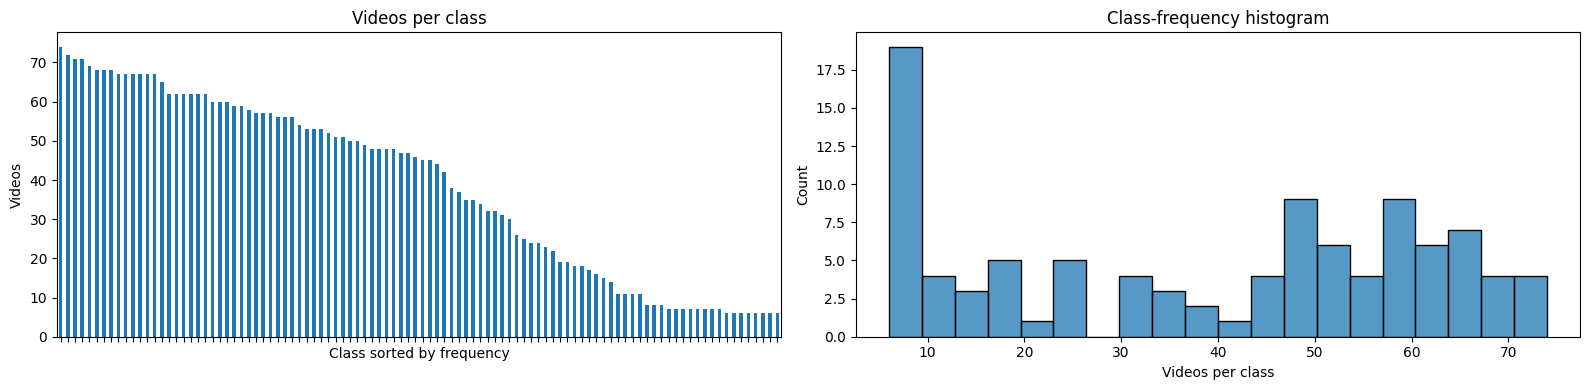

Interpretation:
- If the ratio is large and many classes are in the tail, balanced sampling is justified for Macro-F1.
- If imbalance is mild, a normal shuffled DataLoader may be enough.


In [5]:
counts = pd.Series(class_counts).sort_values(ascending=False)
imbalance_ratio = float(counts.max() / max(1, counts.min()))

q75 = counts.quantile(0.75)
q25 = counts.quantile(0.25)
def class_group(n):
    if n >= q75:
        return "head"
    if n <= q25:
        return "tail"
    return "body"
group_counts = counts.apply(class_group).value_counts()

print("Class count summary:")
print(counts.describe())
print("Imbalance ratio max/min:", round(imbalance_ratio, 2))
print("Head/body/tail groups:")
print(group_counts)
print("Top 10 classes:")
print(counts.head(10))
print("Bottom 10 classes:")
print(counts.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Videos per class")
axes[0].set_xlabel("Class sorted by frequency")
axes[0].set_ylabel("Videos")
axes[0].tick_params(axis="x", labelbottom=False)
sns.histplot(counts.values, bins=20, ax=axes[1])
axes[1].set_title("Class-frequency histogram")
axes[1].set_xlabel("Videos per class")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- If the ratio is large and many classes are in the tail, balanced sampling is justified for Macro-F1.")
print("- If imbalance is mild, a normal shuffled DataLoader may be enough.")


## 5. EDA - Temporal Length, FPS, Duration

Câu hỏi: video dài/ngắn thế nào? Đây là bằng chứng chính trước khi cố định số frame đầu vào. Ta xem frame count, FPS, duration, và coverage của các mốc 8/16/24/32 frames.


Reading video metadata:   0%|          | 0/3875 [00:00<?, ?it/s]

Video probe count: 3875 of 3875
Unreadable/invalid videos: 0
Frame count summary:
count    3875.000000
mean       29.876129
std         1.263905
min        16.000000
5%         30.000000
10%        30.000000
25%        30.000000
50%        30.000000
75%        30.000000
90%        30.000000
95%        30.000000
max        30.000000
Name: frames, dtype: float64
FPS summary:
count    3875.000000
mean       12.935300
std         3.110329
min         0.850000
25%        10.976000
50%        12.336000
75%        14.063000
max        30.018000
Name: fps, dtype: float64
Duration summary (seconds):
count    3875.000000
mean        2.481164
std         1.357125
min         0.700070
5%          1.552152
10%         1.632387
25%         2.133257
50%         2.431907
75%         2.733236
90%         3.125000
95%         3.266551
max        35.294118
Name: duration, dtype: float64


,target_frames,videos_with_at_least_t_frames,coverage,videos_needing_padding
0,8,3875,1.00000,0
1,16,3875,1.00000,0
2,24,3839,0.99071,36
3,32,0,0.00000,3875


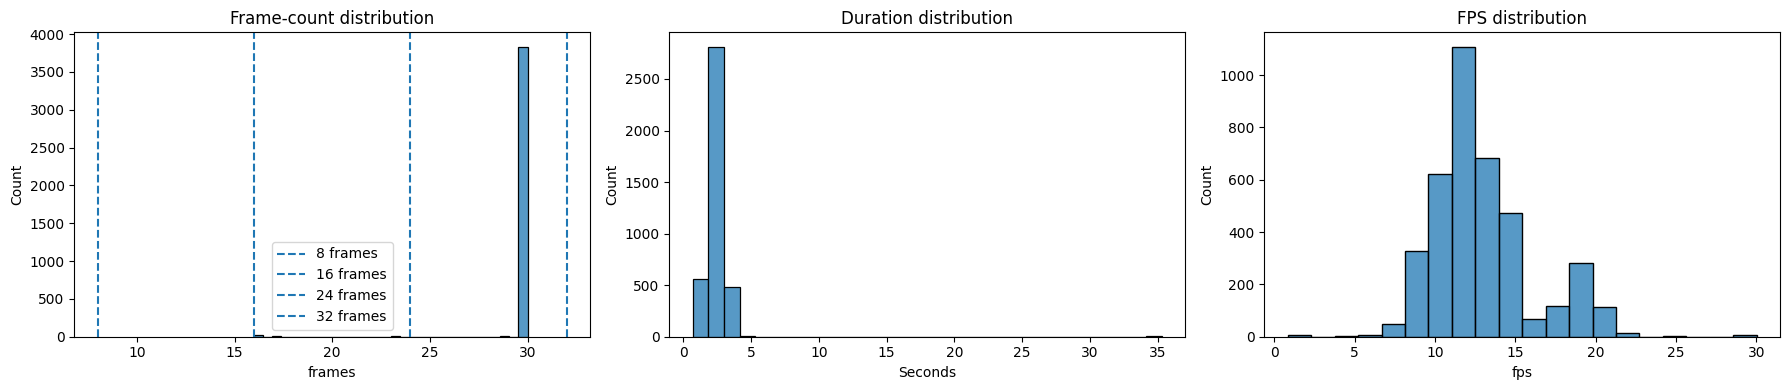

Interpretation:
- Pick a fixed T only after checking coverage. T=16 is reasonable only if most videos have >=16 frames.
- Uniform sampling is preferred over taking the first T frames because signs unfold across the whole clip.
- Padding short clips repeats the last valid frame; if many clips need padding, reconsider T.


In [6]:
probe_items = all_items if MAX_VIDEO_PROBE is None else all_items[:MAX_VIDEO_PROBE]
video_stats = []
unreadable_videos = []

for item in tqdm(probe_items, desc="Reading video metadata"):
    cap = cv2.VideoCapture(item["path"])
    opened = cap.isOpened()
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if opened else 0
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0) if opened else 0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) if opened else 0
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) if opened else 0
    cap.release()
    if (not opened) or frame_count <= 0 or width <= 0 or height <= 0:
        unreadable_videos.append(item["path"])
    video_stats.append({
        "path": item["path"],
        "video_name": item["video_name"],
        "class_name": item["class_name"],
        "label": item["label"],
        "frames": frame_count,
        "fps": fps,
        "duration": frame_count / fps if fps else np.nan,
        "width": width,
        "height": height,
        "aspect_ratio": width / height if height else np.nan,
    })

video_df = pd.DataFrame(video_stats)
print("Video probe count:", len(video_df), "of", len(all_items))
print("Unreadable/invalid videos:", len(unreadable_videos))
print("Frame count summary:")
print(video_df["frames"].describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]))
print("FPS summary:")
print(video_df["fps"].replace(0, np.nan).describe())
print("Duration summary (seconds):")
print(video_df["duration"].describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]))

coverage_rows = []
for t in [8, 16, 24, 32]:
    coverage_rows.append({
        "target_frames": t,
        "videos_with_at_least_t_frames": int((video_df["frames"] >= t).sum()),
        "coverage": float((video_df["frames"] >= t).mean()),
        "videos_needing_padding": int((video_df["frames"] < t).sum()),
    })
coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(video_df["frames"], bins=30, ax=axes[0])
for t in [8, 16, 24, 32]:
    axes[0].axvline(t, linestyle="--", label=f"{t} frames")
axes[0].set_title("Frame-count distribution")
axes[0].legend()
sns.histplot(video_df["duration"].dropna(), bins=30, ax=axes[1])
axes[1].set_title("Duration distribution")
axes[1].set_xlabel("Seconds")
sns.histplot(video_df["fps"].replace(0, np.nan).dropna(), bins=20, ax=axes[2])
axes[2].set_title("FPS distribution")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Pick a fixed T only after checking coverage. T=16 is reasonable only if most videos have >=16 frames.")
print("- Uniform sampling is preferred over taking the first T frames because signs unfold across the whole clip.")
print("- Padding short clips repeats the last valid frame; if many clips need padding, reconsider T.")


## 6. EDA - Spatial Resolution And Aspect Ratio

Câu hỏi: frame có kích thước/khung hình thế nào? Đây là bằng chứng trước khi resize/crop về `224x224`.


,width,height,count
0,224,224,3875


Aspect ratio summary:
count    3875.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64
Fraction near 224-ish resolution: 1.0
Fraction near square aspect ratio: 1.0


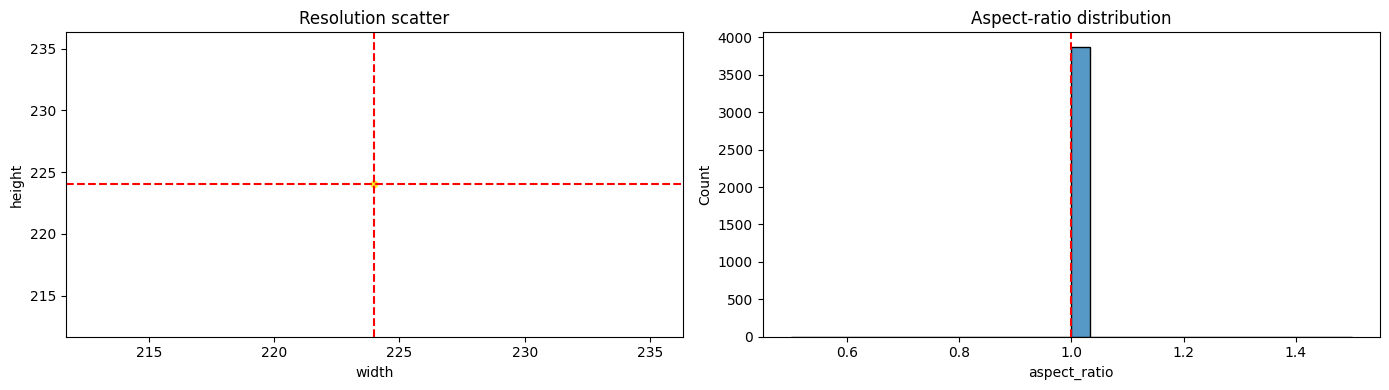

Interpretation:
- If videos are mostly square and near 224, resize/crop to 224 preserves most information.
- 224 also matches the pretrained VideoMAE image processor, so it avoids unnecessary architectural changes.


In [7]:
resolution_counts = video_df.groupby(["width", "height"]).size().sort_values(ascending=False).reset_index(name="count")
display(resolution_counts.head(15))
print("Aspect ratio summary:")
print(video_df["aspect_ratio"].replace([np.inf, -np.inf], np.nan).describe())

near_224 = ((video_df["width"].between(200, 256)) & (video_df["height"].between(200, 256))).mean()
squareish = (video_df["aspect_ratio"].between(0.9, 1.1)).mean()
print("Fraction near 224-ish resolution:", round(float(near_224), 3))
print("Fraction near square aspect ratio:", round(float(squareish), 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(data=video_df, x="width", y="height", hue="frames", palette="viridis", ax=axes[0], legend=False)
axes[0].axvline(224, color="red", linestyle="--")
axes[0].axhline(224, color="red", linestyle="--")
axes[0].set_title("Resolution scatter")
sns.histplot(video_df["aspect_ratio"].dropna(), bins=30, ax=axes[1])
axes[1].axvline(1.0, color="red", linestyle="--")
axes[1].set_title("Aspect-ratio distribution")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- If videos are mostly square and near 224, resize/crop to 224 preserves most information.")
print("- 224 also matches the pretrained VideoMAE image processor, so it avoids unnecessary architectural changes.")


## 7. EDA - Bad Frames And Technical Noise

Câu hỏi: có video/frame lỗi không? Ta không xóa dữ liệu ở đây; chỉ report để biết rủi ro trước khi train.


Scanning sampled frames for technical issues:   0%|          | 0/3875 [00:00<?, ?it/s]

Videos with any sampled bad frame: 756
Videos with >=50% sampled bad frames: 336


,path,video_name,class_name,bad_ratio,sampled_frames
1699,/content/drive/MyDrive/vsl-recognition/data/ol...,885339_1.mp4,Khai báo,1.0000,16
1698,/content/drive/MyDrive/vsl-recognition/data/ol...,885339.mp4,Khai báo,1.0000,16
1700,/content/drive/MyDrive/vsl-recognition/data/ol...,885339_2.mp4,Khai báo,1.0000,16
443,/content/drive/MyDrive/vsl-recognition/data/ol...,214576.mp4,Biết,1.0000,16
863,/content/drive/MyDrive/vsl-recognition/data/ol...,984642.mp4,Chân,0.6875,16
6,/content/drive/MyDrive/vsl-recognition/data/ol...,133326.mp4,An ủi,0.6875,16
7,/content/drive/MyDrive/vsl-recognition/data/ol...,133326_1.mp4,An ủi,0.6875,16
3725,/content/drive/MyDrive/vsl-recognition/data/ol...,651231.mp4,Đầu,0.6875,16
1662,/content/drive/MyDrive/vsl-recognition/data/ol...,362529.mp4,Khai báo,0.6875,16
71,/content/drive/MyDrive/vsl-recognition/data/ol...,678856.mp4,Áp dụng,0.6875,16


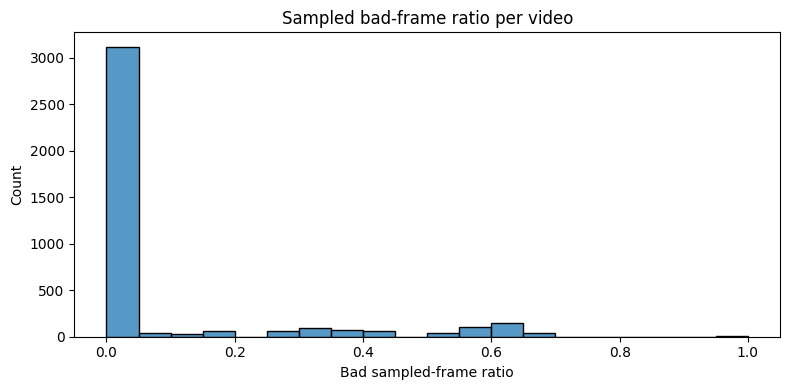

Interpretation:
- This is a conservative sampled-frame scan, not a deletion rule.
- If many videos have high bad ratios, consider filtering bad frames before uniform sampling in a later experiment.


In [8]:
def sample_frame_indices(total, n):
    if total <= 0:
        return []
    n = min(n, total)
    return np.linspace(0, total - 1, n, dtype=int).tolist()

def read_sampled_frames(video_path, n=16):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = set(sample_frame_indices(total, n))
    frames = []
    idx = 0
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break
        if idx in indices:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        idx += 1
        if len(frames) >= len(indices):
            break
    cap.release()
    return frames

def is_solid_or_blank(frame):
    if frame is None or frame.size == 0:
        return True
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    mean = float(gray.mean())
    std = float(gray.std())
    # Low std catches solid-color frames; extreme mean catches near-black/white frames.
    return std < 3.0 or mean < 3.0 or mean > 252.0

bad_frame_reports = []
for item in tqdm(probe_items, desc="Scanning sampled frames for technical issues"):
    frames = read_sampled_frames(item["path"], BAD_FRAME_SAMPLE_COUNT)
    if not frames:
        bad_frame_reports.append({"path": item["path"], "class_name": item["class_name"], "bad_ratio": 1.0, "sampled_frames": 0})
        continue
    bad_count = sum(is_solid_or_blank(frame) for frame in frames)
    bad_frame_reports.append({
        "path": item["path"],
        "video_name": item["video_name"],
        "class_name": item["class_name"],
        "bad_ratio": bad_count / len(frames),
        "sampled_frames": len(frames),
    })

bad_df = pd.DataFrame(bad_frame_reports).sort_values("bad_ratio", ascending=False)
print("Videos with any sampled bad frame:", int((bad_df["bad_ratio"] > 0).sum()))
print("Videos with >=50% sampled bad frames:", int((bad_df["bad_ratio"] >= 0.5).sum()))
display(bad_df.head(15))

plt.figure(figsize=(8, 4))
sns.histplot(bad_df["bad_ratio"], bins=20)
plt.title("Sampled bad-frame ratio per video")
plt.xlabel("Bad sampled-frame ratio")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- This is a conservative sampled-frame scan, not a deletion rule.")
print("- If many videos have high bad ratios, consider filtering bad frames before uniform sampling in a later experiment.")


## 8. EDA - Duplicate Candidates

Câu hỏi: có video trùng hoặc gần trùng không? Ta chỉ tạo signature nhẹ để report nghi ngờ, không tự động xóa.


In [9]:
def frame_signature(frame, size=16):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    small = cv2.resize(gray, (size, size), interpolation=cv2.INTER_AREA)
    mean = small.mean()
    bits = (small > mean).astype(np.uint8).flatten()
    return "".join(map(str, bits.tolist()))

def video_signature(video_path, n_frames=5):
    frames = read_sampled_frames(video_path, n_frames)
    if not frames:
        return None
    sig = "|".join(frame_signature(frame) for frame in frames)
    return hashlib.md5(sig.encode("utf-8")).hexdigest()

signature_to_items = defaultdict(list)
for item in tqdm(probe_items, desc="Computing lightweight duplicate signatures"):
    sig = video_signature(item["path"], DUPLICATE_SIGNATURE_FRAMES)
    if sig:
        signature_to_items[sig].append(item)

duplicate_groups = [items for items in signature_to_items.values() if len(items) > 1]
duplicate_rows = []
for group_id, group in enumerate(duplicate_groups):
    for item in group:
        duplicate_rows.append({
            "group": group_id,
            "class_name": item["class_name"],
            "video_name": item["video_name"],
            "path": item["path"],
        })
duplicate_df = pd.DataFrame(duplicate_rows)
print("Duplicate candidate groups:", len(duplicate_groups))
print("Videos in duplicate candidate groups:", len(duplicate_df))
if len(duplicate_df):
    display(duplicate_df.head(30))
else:
    print("No exact signature duplicates found in the probed set.")

print("Interpretation:")
print("- Signature duplicates are only candidates; visually inspect before removing anything.")
print("- For tail classes, duplicate removal can hurt sample count, so do not delete automatically.")


Computing lightweight duplicate signatures:   0%|          | 0/3875 [00:00<?, ?it/s]

Duplicate candidate groups: 551
Videos in duplicate candidate groups: 1653


,group,class_name,video_name,path
0,0,An ủi,127824.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
1,0,An ủi,127824_1.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
2,0,An ủi,127824_2.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
3,0,An ủi,127824_3.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
4,1,An ủi,133326.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
5,1,An ủi,133326_1.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
6,2,An ủi,198246.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
7,2,An ủi,198246_1.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
8,2,An ủi,198246_2.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...
9,3,An ủi,876646.mp4,/content/drive/MyDrive/vsl-recognition/data/ol...


Interpretation:
- Signature duplicates are only candidates; visually inspect before removing anything.
- For tail classes, duplicate removal can hurt sample count, so do not delete automatically.


## 9. Visual Samples: Head / Body / Tail Classes

Câu hỏi: video thật nhìn như thế nào ở các nhóm class khác nhau? Phần này giúp reviewer thấy dữ liệu và cũng giúp chọn augmentation hợp lý.


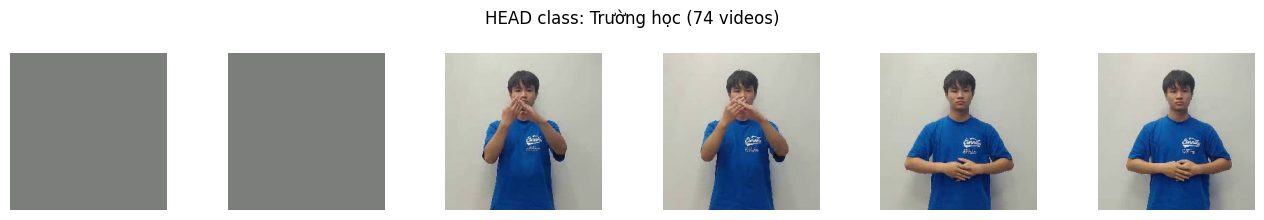

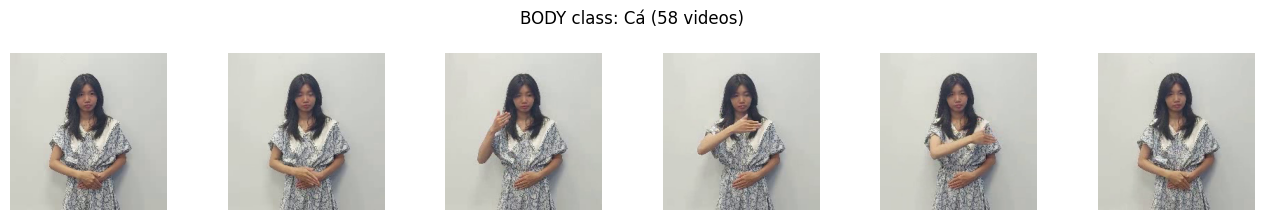

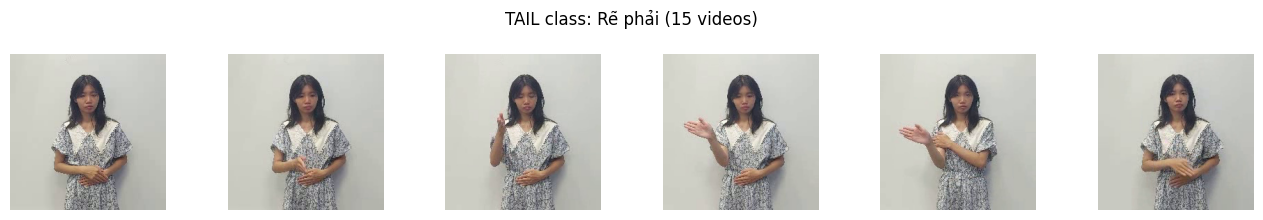

Interpretation:
- Consistent crop/color jitter is suitable when signer position and lighting vary.
- Horizontal flip is not used by default because left/right orientation can matter in sign language.


In [10]:
def pick_class_by_group(group_name):
    candidates = [name for name, n in counts.items() if class_group(n) == group_name]
    return candidates[0] if candidates else counts.index[0]

def show_video_strip(video_path, title, n=6):
    frames = read_sampled_frames(video_path, n)
    if not frames:
        print("Cannot read", video_path)
        return
    fig, axes = plt.subplots(1, len(frames), figsize=(2.2 * len(frames), 2.2))
    if len(frames) == 1:
        axes = [axes]
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

for group in ["head", "body", "tail"]:
    cls = pick_class_by_group(group)
    item = next(item for item in all_items if item["class_name"] == cls)
    show_video_strip(item["path"], f"{group.upper()} class: {cls} ({class_counts[cls]} videos)")

print("Interpretation:")
print("- Consistent crop/color jitter is suitable when signer position and lighting vary.")
print("- Horizontal flip is not used by default because left/right orientation can matter in sign language.")


## 10. Create Stratified Train/Val Split And Save Metadata

Sau khi EDA xác nhận cấu trúc dataset, tạo split 80/20 theo class. Không dùng public/private test vì chúng không có label.


In [11]:
random.seed(SEED)

# Duplicate-aware split:
# - If duplicate signatures were computed above, keep all videos from the same signature group in the same split.
# - This prevents near-identical copies like xxx.mp4 / xxx_1.mp4 from leaking across train and validation.
# - We do not delete duplicates here; we only split them safely.
path_to_dup_group = {}
if "duplicate_groups" in globals():
    for group_id, group in enumerate(duplicate_groups):
        for item in group:
            path_to_dup_group[item["path"]] = f"dup_{group_id}"

def split_class_items_duplicate_aware(items, val_ratio=0.2):
    grouped = defaultdict(list)
    for item in items:
        group_key = path_to_dup_group.get(item["path"], f"single_{item["path"]}")
        grouped[group_key].append(item)

    groups = list(grouped.values())
    random.shuffle(groups)
    total = sum(len(g) for g in groups)
    if total <= 1:
        return [item for group in groups for item in group], []

    target_val = max(1, round(total * val_ratio))
    val_groups, train_groups = [], []
    val_count = 0

    # Split at group level to prevent duplicate leakage.
    # Random order keeps validation closer to the original distribution than always choosing small groups.
    for group in groups:
        can_move_to_val = val_count < target_val and (total - val_count - len(group)) >= 1
        if can_move_to_val:
            val_groups.append(group)
            val_count += len(group)
        else:
            train_groups.append(group)

    if not val_groups and len(train_groups) > 1:
        val_groups.append(train_groups.pop())

    train = [item for group in train_groups for item in group]
    val = [item for group in val_groups for item in group]
    return train, val

train_items, val_items = [], []
for class_name in class_names:
    items = [item for item in all_items if item["class_name"] == class_name]
    cls_train, cls_val = split_class_items_duplicate_aware(items, VAL_RATIO)
    train_items.extend(cls_train)
    val_items.extend(cls_val)

random.shuffle(train_items)
random.shuffle(val_items)

# Sanity check: no duplicate signature group should appear in both train and val.
train_groups = {path_to_dup_group[item["path"]] for item in train_items if item["path"] in path_to_dup_group}
val_groups = {path_to_dup_group[item["path"]] for item in val_items if item["path"] in path_to_dup_group}
leaked_groups = sorted(train_groups & val_groups)

metadata_dir = Path(METADATA_DIR)
metadata_dir.mkdir(parents=True, exist_ok=True)
with open(metadata_dir / "train.json", "w", encoding="utf-8") as f:
    json.dump(train_items, f, ensure_ascii=False, indent=2)
with open(metadata_dir / "val.json", "w", encoding="utf-8") as f:
    json.dump(val_items, f, ensure_ascii=False, indent=2)
with open(metadata_dir / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

train_counts = pd.Series(Counter(item["class_name"] for item in train_items)).sort_values(ascending=False)
val_counts = pd.Series(Counter(item["class_name"] for item in val_items)).sort_values(ascending=False)
split_stats = pd.DataFrame({"total": counts, "train": train_counts, "val": val_counts}).fillna(0).astype(int)
display(split_stats.head(10))
display(split_stats.tail(10))

print("Total classes:", len(class_names))
print("Train videos:", len(train_items))
print("Val videos:", len(val_items))
print("Duplicate groups crossing train/val:", len(leaked_groups))
if leaked_groups[:10]:
    print("Leaked group examples:", leaked_groups[:10])
print("Metadata saved to:", metadata_dir)



,total,train,val
An ủi,32,25,7
Áp dụng,71,56,15
Ăn,60,48,12
Ăn mừng,62,49,13
Ban ngày,23,18,5
Ban đêm,7,5,2
Bàn tay,8,6,2
Băn khoăn,62,49,13
Bạn thân,18,14,4
Bế mạc,35,28,7


,total,train,val
Xe đạp,16,12,4
Xin lỗi,19,15,4
Xin phép,38,30,8
Xuất viện,48,38,10
Xúc động,59,47,12
Đâu,53,42,11
Đầu,54,43,11
Đẹp,18,14,4
Đi,62,49,13
Đồng ý,53,42,11


Total classes: 100
Train videos: 3052
Val videos: 823
Metadata saved to: /content/drive/MyDrive/vsl-recognition/metadata


## 11. Save EDA Summary

Lưu thống kê EDA để xem lại sau, nhưng không lưu “quyết định model”. Các quyết định vẫn được giải thích bằng output/biểu đồ trong notebook.


In [ ]:
eda_summary = {
    "project_root": PROJECT_ROOT,
    "dataset_root": str(DATASET_ROOT),
    "num_classes": len(class_names),
    "num_total_train_videos": len(all_items),
    "num_train_split_videos": len(train_items),
    "num_val_split_videos": len(val_items),
    "num_public_test_videos": count_videos(PUBLIC_TEST_DIR),
    "num_private_test_videos": count_videos(PRIVATE_TEST_DIR),
    "class_counts": dict(class_counts),
    "class_imbalance_ratio": imbalance_ratio,
    "video_probe_count": len(video_df),
    "video_probe_is_full": MAX_VIDEO_PROBE is None,
    "unreadable_video_count": len(unreadable_videos),
    "videos_with_any_sampled_bad_frame": int((bad_df["bad_ratio"] > 0).sum()),
    "videos_with_ge_50pct_sampled_bad_frames": int((bad_df["bad_ratio"] >= 0.5).sum()),
    "duplicate_candidate_groups": len(duplicate_groups),
    "duplicate_candidate_videos": int(len(duplicate_df)) if len(duplicate_df) else 0,
    "duplicate_groups_crossing_train_val": len(leaked_groups),
    "video_metadata_summary": {
        "frames": video_df["frames"].describe().to_dict(),
        "duration": video_df["duration"].describe().to_dict(),
        "fps": video_df["fps"].replace(0, np.nan).describe().to_dict(),
    },
    "frame_coverage": coverage_df.to_dict(orient="records"),
}
with open(metadata_dir / "dataset_stats.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, ensure_ascii=False, indent=2)
print("dataset_stats.json saved to:", metadata_dir / "dataset_stats.json")


dataset_stats.json saved to: /content/drive/MyDrive/vsl-recognition/metadata/dataset_stats.json


## 12. Quick Preprocessing Test

Câu hỏi cuối: nếu chọn T=16 và 224x224 thì sample tensor có đúng shape để đưa vào VideoMAE không?


In [13]:
def read_all_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    if not frames:
        raise ValueError(f"Cannot read video: {video_path}")
    return np.asarray(frames)

def sample_uniform_frames(video_path, num_frames=16):
    frames = read_all_frames(video_path)
    total = len(frames)
    if total >= num_frames:
        indices = np.linspace(0, total - 1, num_frames, dtype=int)
    else:
        indices = np.concatenate([np.arange(total), np.full(num_frames - total, total - 1, dtype=int)])
    return frames[indices]

sample = train_items[0]
frames = sample_uniform_frames(sample["path"], 16)
print("Sample class:", sample["class_name"], "label:", sample["label"])
print("Uniform sampled frames:", frames.shape, frames.dtype)
print("Notebook 01 done. Use these EDA outputs to justify notebook 02 config before training.")


Sample class: Trưa label: 82
Uniform sampled frames: (16, 224, 224, 3) uint8
Notebook 01 done. Use these EDA outputs to justify notebook 02 config before training.
